In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re


In [22]:
project = 'Antarctic'

excel_path = f'/Users/quinnmackay/Documents/GitHub/BICC/Antarctic Chronology Accuracy Project/table_out/{project}_full.xlsx'

load_network_data = pd.read_excel(excel_path, usecols='B:V')
load_code_data = pd.read_excel(excel_path, sheet_name=1, usecols='T:AC')
load_reference_data = pd.read_excel(excel_path, sheet_name=1, usecols='H:Q')

In [23]:
load_network_data

,EDC,WDC,EDC.1,EDML,EDC.2,DF,EDC.3,TALDICE,WDC.1,EDML.1,...,DF.1,WDC.3,TALDICE.1,EDML.2,DF.2,EDML.3,TALDICE.2,DF.3,TALDICE.3,Within Row Errors
0,NaN,NaN,8.17,17.19,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.149600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.548118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.390400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,12.16,24.94,12.11,11.26,12.160086,29.56,NaN,NaN,...,11.259500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2557,NaN,NaN,NaN,NaN,2161.98,2178.26,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2558,NaN,NaN,NaN,NaN,2163.18,2179.03,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2559,NaN,NaN,NaN,NaN,2163.64,2179.33,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2560,NaN,NaN,NaN,NaN,2164.54,2180.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


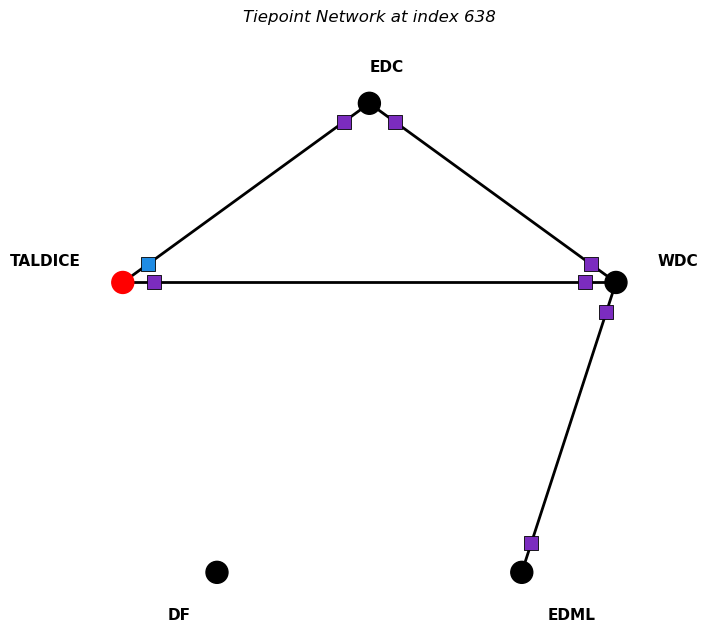

In [24]:
# 2D pentagon tiepoint diagram for any row index in load_network_data

def _canonical_core_name(name: str) -> str:
    """Collapse pandas duplicate-column suffixes like .1, .2 back to base core name."""
    return re.sub(r"\.\d+$", "", str(name))


def _parse_error_cores(error_value) -> set[str]:
    """Return a set of core names mentioned in the Within Row Errors cell."""
    if pd.isna(error_value):
        return set()

    if isinstance(error_value, (list, tuple, set)):
        tokens = [str(item) for item in error_value]
    else:
        tokens = re.split(r"[,;/|\n]+", str(error_value))

    return {_canonical_core_name(token).strip() for token in tokens if str(token).strip()}


def _cluster_depth_colors(depths, palette, tolerance=0.15):
    """Assign stable colors to depth clusters using a simple tolerance-based grouping."""
    clusters = []
    colors = []

    for depth in depths:
        matched_index = None
        for cluster_index, cluster in enumerate(clusters):
            if abs(depth - cluster["representative"]) <= tolerance:
                matched_index = cluster_index
                break

        if matched_index is None:
            cluster_index = len(clusters)
            if cluster_index >= len(palette):
                raise ValueError(
                    f"Need at most {len(palette)} distinct depth groups, but found more at this index"
                )
            clusters.append({"representative": depth, "color": palette[cluster_index]})
            colors.append(palette[cluster_index])
        else:
            cluster = clusters[matched_index]
            cluster["representative"] = (cluster["representative"] + depth) / 2
            colors.append(cluster["color"])

    return colors


def plot_tiepoint_pentagon(load_network_data: pd.DataFrame, idx: int, cores=None, save=False):
    """Plot a 5-vertex pentagon where edges represent tiepoints at row idx.

    Rules:
    - Each pair of consecutive columns is treated as one tiepoint pair.
    - If both values are non-missing at idx, that pair is considered active.
    - Duplicate pandas suffixes in column names (e.g., EDC.1) are normalized.
    - Any core name listed in the 'Within Row Errors' column is colored red.
    - Squares near line endpoints are colored by depth groups using a 0.15 m tolerance.
    """
    if not isinstance(load_network_data, pd.DataFrame):
        raise TypeError("load_network_data must be a pandas DataFrame")

    if idx not in load_network_data.index:
        raise IndexError(f"Index {idx} is not present in load_network_data.index")

    error_column = "Within Row Errors"
    if error_column not in load_network_data.columns:
        raise KeyError(f"Missing required column: {error_column}")

    raw_cols = [column for column in load_network_data.columns if column != error_column]
    if len(raw_cols) < 10:
        raise ValueError("Need at least 10 core columns (5 tiepoint pairs) to define a 5-core network")

    if len(raw_cols) % 2 != 0:
        raw_cols = raw_cols[:-1]

    # Build raw-pair list: (raw_col_1, raw_col_2, core_1, core_2)
    pairs = []
    for i in range(0, len(raw_cols), 2):
        r1, r2 = raw_cols[i], raw_cols[i + 1]
        c1, c2 = _canonical_core_name(r1), _canonical_core_name(r2)
        pairs.append((r1, r2, c1, c2))

    # Ordered unique core list from pair definitions.
    ordered_cores = []
    for _, _, c1, c2 in pairs:
        if c1 not in ordered_cores:
            ordered_cores.append(c1)
        if c2 not in ordered_cores:
            ordered_cores.append(c2)

    if cores is None:
        cores = ordered_cores[:5]
    else:
        cores = list(cores)

    if len(cores) != 5:
        raise ValueError("cores must contain exactly 5 ice core names")

    row = load_network_data.loc[idx]
    error_cores = _parse_error_cores(row[error_column])

    palette = ["#7B2CBF", "#1F8CE4", "#F4A261", "#E824C4"]  # Purple, Green, Orange, Light Blue
    line_color = "#000000"
    error_color = "red"

    # Collect active edges and per-core depth values for this row.
    active_edges = []
    core_depths = {core: [] for core in cores}
    for r1, r2, c1, c2 in pairs:
        if c1 in cores and c2 in cores and c1 != c2:
            if pd.notna(row[r1]) and pd.notna(row[r2]):
                edge = tuple(sorted((c1, c2)))
                active_edges.append((edge[0], edge[1], float(row[r1]), float(row[r2])))
                core_depths[c1].append(float(row[r1]))
                core_depths[c2].append(float(row[r2]))

    # Determine a color for each depth associated with each core.
    core_depth_color_map = {}
    for core in cores:
        depths = core_depths[core]
        if depths:
            sorted_pairs = sorted(enumerate(depths), key=lambda item: item[1])
            sorted_depths = [depth for _, depth in sorted_pairs]
            sorted_colors = _cluster_depth_colors(sorted_depths, palette, tolerance=0.15)
            colors_in_original_order = [None] * len(depths)
            for (original_index, _), color in zip(sorted_pairs, sorted_colors):
                colors_in_original_order[original_index] = color
            core_depth_color_map[core] = list(zip(depths, colors_in_original_order))
        else:
            core_depth_color_map[core] = []

    # Pentagon coordinates (clockwise), starting at top.
    angles = np.deg2rad([90, 18, -54, -126, 162])
    pos = {core: (np.cos(a), np.sin(a)) for core, a in zip(cores, angles)}

    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw active tiepoint lines.
    for c1, c2, _, _ in active_edges:
        x1, y1 = pos[c1]
        x2, y2 = pos[c2]
        ax.plot([x1, x2], [y1, y2], color=line_color, linewidth=2, zorder=1)

    # Draw colored squares near line endpoints based on depth group.
    square_offset = 0.12
    square_size = 110
    used_depth_counts = {core: 0 for core in cores}

    for c1, c2, d1, d2 in active_edges:
        for core, depth in ((c1, d1), (c2, d2)):
            depth_index = used_depth_counts[core]
            used_depth_counts[core] += 1
            color = core_depth_color_map[core][depth_index][1] if depth_index < len(core_depth_color_map[core]) else line_color

            x0, y0 = pos[core]
            other_core = c2 if core == c1 else c1
            x1, y1 = pos[other_core]
            dx, dy = x1 - x0, y1 - y0
            norm = (dx * dx + dy * dy) ** 0.5
            if norm == 0:
                continue
            ux, uy = dx / norm, dy / norm
            xs = x0 + ux * square_offset
            ys = y0 + uy * square_offset
            ax.scatter([xs], [ys], marker='s', s=square_size, c=[color], edgecolors='black', linewidths=0.6, zorder=4)

    # Draw core vertices.
    xs = [pos[c][0] for c in cores]
    ys = [pos[c][1] for c in cores]
    vertex_colors = [error_color if c in error_cores else line_color for c in cores]
    ax.scatter(xs, ys, s=250, c=vertex_colors, zorder=5)

    label_offset = 0.17
    for c in cores:
        x, y = pos[c]
        radius = (x * x + y * y) ** 0.5
        if radius == 0:
            lx, ly = x, y
            ha, va = 'center', 'center'
        else:
            lx = x + (x / radius) * label_offset
            ly = y + (y / radius) * label_offset
            ha = 'left' if x >= 0 else 'right'
            if y > 0.8:
                va = 'top'
            else:
                va = 'bottom' if y >= 0 else 'top'
        ax.text(lx, ly, c, ha=ha, va=va, fontsize=11, fontweight='bold')

    ax.set_title(f"Tiepoint Network at index {idx}", pad=42, fontstyle='italic')
    ax.set_aspect('equal')
    ax.axis('off')
    if save:
        plt.savefig(f'/Users/quinnmackay/Desktop/network_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_tiepoint_pentagon(load_network_data, idx=638, save=False)